# Argentine Senate floor speech, 2020–2024 — first analysis

First analysis of the ar_congress corpus: all 90 stenographic session
transcripts (versiones taquigráficas) published by the Senado de la Nación
for 2020–2024, parsed into speaker-attributed speech turns and typed
stenographer events (parser 0.3.1), with speakers resolved to persons
(99.95% of speech blocks). Provenance and terms: [SOURCES.md](../SOURCES.md).


In [1]:
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BLOCKS = ROOT / "data" / "processed" / "senado" / "blocks"

corpus = pd.concat([pd.read_parquet(p) for p in sorted(BLOCKS.glob("*.parquet"))], ignore_index=True)
speakers = pd.read_parquet(ROOT / "data" / "processed" / "senado" / "speakers.parquet")

speech = corpus[corpus.type == "speech"].merge(
    speakers[["session_id", "speaker_raw", "person_id", "person_name", "party", "province", "match_status"]],
    on=["session_id", "speaker_raw"], how="left",
)
speech["words"] = speech.text.str.split().str.len()
speech["year"] = speech.session_date.str[:4].astype(int)
corpus["year"] = corpus.session_date.str[:4].astype(int)

print(f"{corpus.session_id.nunique()} sessions | {len(corpus):,} rows | "
      f"{len(speech):,} speech turns | {speech.words.sum():,} words spoken")

Matplotlib is building the font cache; this may take a moment.


90 sessions | 34,718 rows | 22,948 speech turns | 3,635,895 words spoken


## Sampling frame — read this before trusting any trend

The 2020–2024 window is **not** a neutral sample of Senate activity:

- **2020 is the COVID remote-procedure era**: 32 sessions, most of type
  ESPECIAL (52 of the 90 sessions overall are ESPECIAL). Session counts
  collapse to 12 by 2023 (an election year).
- **Asambleas Legislativas are not Senate debate** — they are joint
  sessions where the President of the Nation speaks (State-of-the-Nation
  addresses, inaugurations). They stay in the corpus but are excluded
  from floor-speech analyses below.
- **Alliance ≠ caucus.** The roster records each senator's *electoral
  alliance* per mandate; caucus (bloque) membership is only published for
  sitting senators. Groupings below are alliance-lineage based and coarse
  by design.


In [2]:
overview = (corpus.groupby(["year", "session_type"]).session_id.nunique()
            .unstack(fill_value=0))
overview["total"] = overview.sum(axis=1)
overview

session_type,ASAMBLEA,EN MINORÍA,ESPECIAL,ESPECIAL EXTRAORDINARIA,EXTRAORDINARIA,INFORMATIVA ESPECIAL,ORDINARIA,ORDINARIA CONTINUACIÓN,PREPARATORIA,total
year,,,,,,,,,,
2020,1,0,21,1,2,2,3,1,1,32
2021,1,0,12,0,2,1,2,0,1,19
2022,1,0,10,0,0,1,1,0,1,14
2023,4,1,4,0,0,1,1,0,1,12
2024,1,0,5,0,0,2,4,0,1,13


## Who holds the floor?

**Floor speech** here means: speech turns by senators speaking from the
floor (`match_status == "matched_senator"`), outside Asambleas. Chair and
officer speech (58% of all blocks!) is excluded as procedural — the
presiding officer's "Tiene la palabra..." traffic would otherwise swamp
every signal.

Alliances are grouped into **electoral-alliance lineages** by the keyword
rules in the next cell — auditable and deliberately coarse. Provincial
alliances (Juntos Somos Río Negro, Unión por Córdoba, Frente Renovador de
la Concordia, ...) stay in their own bucket even where their senators
caucus with a national bloc.


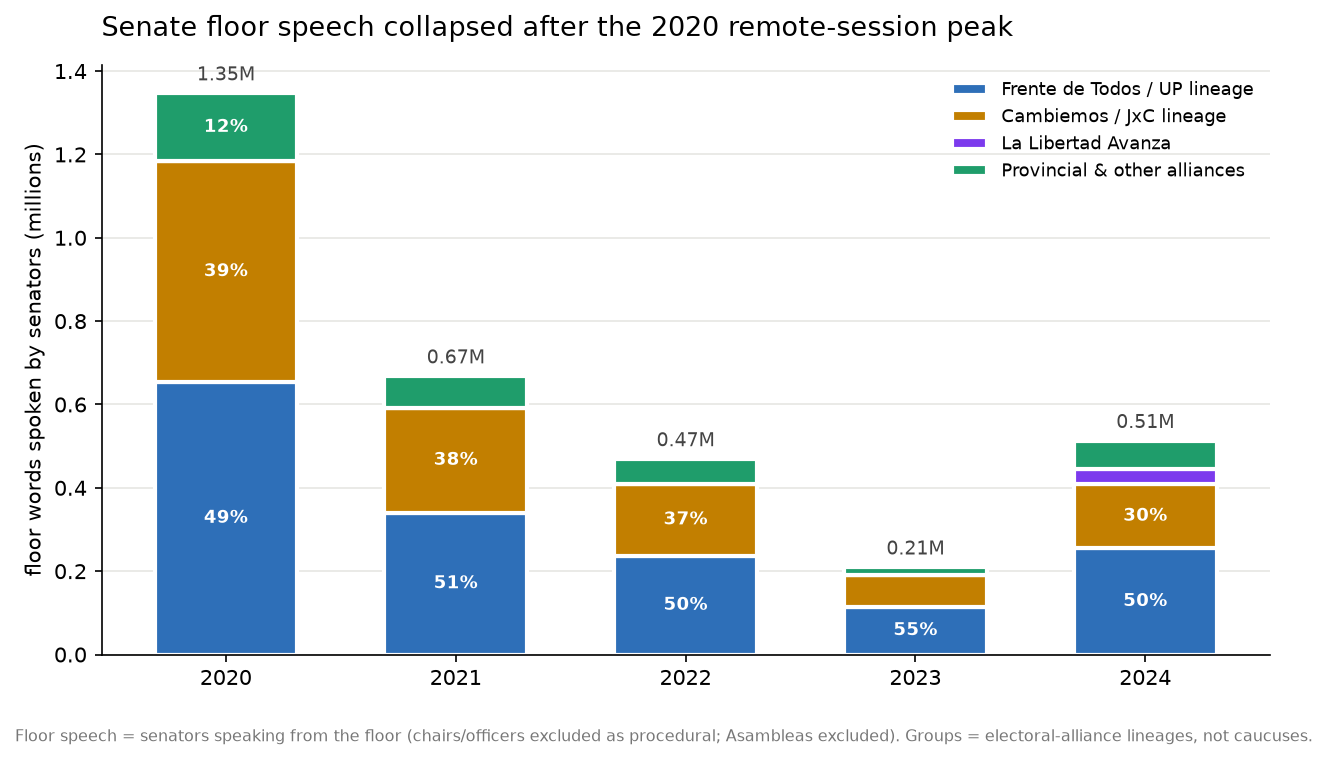

lineage,Frente de Todos / UP lineage,Cambiemos / JxC lineage,La Libertad Avanza,Provincial & other alliances
year,,,,
2020,0.654,0.529,0.000,0.163
2021,0.340,0.252,0.000,0.076
2022,0.236,0.174,0.000,0.059
2023,0.115,0.075,0.001,0.018
2024,0.255,0.155,0.036,0.067


In [3]:
def deaccent(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if not unicodedata.combining(c))

def lineage(alliance):
    a = deaccent(str(alliance or "")).upper()
    if "LIBERTAD AVANZA" in a:
        return "La Libertad Avanza"
    if "CAMBIEMOS" in a or "JUNTOS POR EL CAMBIO" in a:
        return "Cambiemos / JxC lineage"
    if any(k in a for k in ("DE TODOS", "FRENTE TODOS", "PARA LA VICTORIA", "DE LA VICTORIA",
                            "P/VICTORIA", "UNIDAD CIUDADANA", "UNION POR LA PATRIA",
                            "JUSTICIALIS", "PERONIS")):
        return "Frente de Todos / UP lineage"
    return "Provincial & other alliances"

floor = speech[(speech.match_status == "matched_senator") & (speech.session_type != "ASAMBLEA")].copy()
floor["lineage"] = floor.party.map(lineage)

ORDER = ["Frente de Todos / UP lineage", "Cambiemos / JxC lineage",
         "La Libertad Avanza", "Provincial & other alliances"]
COLORS = {"Frente de Todos / UP lineage": "#2E6FB8", "Cambiemos / JxC lineage": "#C27F00",
          "La Libertad Avanza": "#7C3AED", "Provincial & other alliances": "#1F9D6B"}

by_year = (floor.groupby(["year", "lineage"]).words.sum().unstack(fill_value=0)
           .reindex(columns=ORDER, fill_value=0) / 1e6)

fig, ax = plt.subplots(figsize=(8.6, 4.8), dpi=150)
bottom = pd.Series(0.0, index=by_year.index)
for col in ORDER:
    ax.bar(by_year.index, by_year[col], bottom=bottom, width=0.62,
           color=COLORS[col], edgecolor="white", linewidth=2, label=col)
    seg = by_year[col]
    for x, (y0, h) in zip(by_year.index, zip(bottom, seg)):
        if h > 0.08 * by_year.sum(axis=1).max():
            share = h / by_year.sum(axis=1)[x]
            ax.text(x, y0 + h / 2, f"{share:.0%}", ha="center", va="center",
                    color="white", fontsize=8.5, fontweight="bold")
    bottom += seg
for x, total in by_year.sum(axis=1).items():
    ax.text(x, total + 0.02, f"{total:.2f}M", ha="center", va="bottom",
            fontsize=9, color="#444444")

ax.set_title("Senate floor speech collapsed after the 2020 remote-session peak",
             fontsize=13, loc="left", pad=14)
ax.set_ylabel("floor words spoken by senators (millions)")
ax.set_xticks(by_year.index)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f"))
ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper right")
fig.text(0.01, -0.04,
         "Floor speech = senators speaking from the floor (chairs/officers excluded as procedural; Asambleas excluded). "
         "Groups = electoral-alliance lineages, not caucuses.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "floor_words_by_year.png", bbox_inches="tight")
plt.show()

by_year.round(3)

## Chamber temperature

The stenographer events the parser preserves (the original TODO of this
project) allow something transcripts-as-text cannot: measuring what
happened *around* the words. Rates are per 10,000 floor words, so the
activity collapse doesn't masquerade as a mood change.


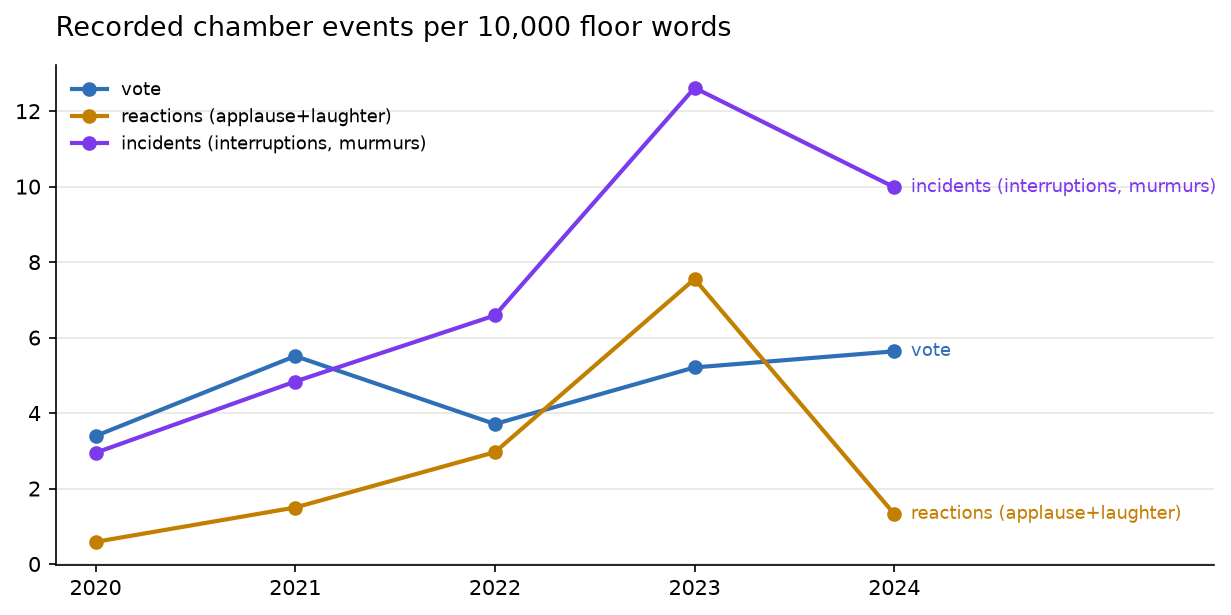

In [4]:
events = corpus[(corpus.type == "event") & (corpus.session_type != "ASAMBLEA")]
fw = floor.groupby("year").words.sum()

KINDS = {
    "vote": ["vote"],
    "reactions (applause+laughter)": ["applause", "laughter"],
    "incidents (interruptions, murmurs)": ["incident"],
}
KCOLORS = {"vote": "#2E6FB8", "reactions (applause+laughter)": "#C27F00",
           "incidents (interruptions, murmurs)": "#7C3AED"}

fig, ax = plt.subplots(figsize=(8.6, 4.2), dpi=150)
for name, subtypes in KINDS.items():
    n = events[events.event_type.isin(subtypes)].groupby("year").size()
    rate = (n / fw * 10_000).reindex(fw.index)
    ax.plot(rate.index, rate.values, marker="o", markersize=6, linewidth=2,
            color=KCOLORS[name], label=name)
    ax.annotate(name, (rate.index[-1], rate.values[-1]),
                xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=KCOLORS[name])

ax.set_title("Recorded chamber events per 10,000 floor words", fontsize=13, loc="left", pad=14)
ax.set_xticks(fw.index)
ax.set_xlim(fw.index.min() - 0.2, fw.index.max() + 1.6)
ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "chamber_temperature.png", bbox_inches="tight")
plt.show()

In [5]:
top = (floor.groupby(["person_name", "province"]).words.sum()
       .sort_values(ascending=False).head(12) / 1000)
top.round(1).rename("floor words (thousands)").to_frame()

,,floor words (thousands)
person_name,province,
"MAYANS, JOSÉ MIGUEL ÁNGEL",FORMOSA,289.2
"PETCOFF NAIDENOFF, LUIS CARLOS",FORMOSA,154.2
"PARRILLI, OSCAR ISIDRO",NEUQUÉN,134.9
"FERNÁNDEZ SAGASTI, ANABEL",MENDOZA,134.6
"LOUSTEAU, MARTÍN",CIUDAD AUTÓNOMA DE BUENOS AIRES,131.0
"ROMERO, JUAN CARLOS",SALTA,89.2
"WERETILNECK, ALBERTO EDGARDO",RÍO NEGRO,69.4
"CASERIO, CARLOS ALBERTO",CÓRDOBA,65.4
"PAIS, JUAN MARIO",CHUBUT,64.4


## Findings (first pass)

1. **Activity collapsed six-fold.** Senator floor speech fell from 1.35M
   words in 2020 (32 remote-era sessions) to 0.21M in the 2023 election
   year, rebounding only partially in 2024 (0.51M). Any cross-period
   comparison must normalize for this.
2. **Composition is stable at the top, rotating at the edges.** The
   Frente de Todos / UP lineage holds roughly half of floor words in
   every single year (49–55%). The Cambiemos/JxC lineage share slides
   from 39% (2020) to 30% (2024); La Libertad Avanza enters in 2024 with
   7% (it seats few senators); provincial alliances fluctuate 4–13%.
3. **Floor time follows leadership, not province size.** The two most
   talkative senators are both from Formosa: José Mayans (289k words,
   bloc chief) and Luis Petcoff Naidenoff (154k, opposition leadership).
4. **The chamber got rowdier as it got quieter.** Recorded incidents
   (interruptions, murmurs, unintelligible content) per 10,000 floor
   words quadrupled from 2.9 (2020) to 12.6 (2023) and stayed elevated
   in 2024 (10.0). The 2023 applause spike rides a thin denominator
   (ceremonial sessions in a near-paralyzed year) — treat with care.

**Caveats carried from the sampling frame:** COVID-era session-type mix,
alliance-lineage grouping (not caucus), chairs/officers excluded, gold
set pending owner audit. **Next:** caucus mapping for departed senators,
pre-2020 extension (the archived listing shows 1,814 sessions back to
the 1990s), and Diputados.
